In [180]:
# library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
import keras.backend as K
sns.set_style("darkgrid")

In [181]:
# check the gpu
devices = tf.config.list_physical_devices()
print("Devices found:", devices)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("Success! GPU is active.")
    # This line tells TF to use the GPU specifically
    tf.config.set_visible_devices(gpu_devices[0], 'GPU')
else:
    print("GPU still not found. You might be running an Intel version of Python.")
import pandas as pd

Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Success! GPU is active.


In [182]:
f = pd.read_parquet('/Users/faizshaikh/Documents/MATLAB/transmission_system/Training_Dataset.parquet')
print(f.head())

                                       TransientData  FaultID  Interface
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...  Fault01       30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...  Fault01       60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...  Fault01       90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...  Fault01       30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...  Fault01       60.0


In [183]:
# update the fault IDs to class
mapping = {
    'LG': ['Fault01', 'Fault02', 'Fault03', 'Fault12', 'Fault13', 'Fault14', 
           'Fault23', 'Fault24', 'Fault25', 'Fault34', 'Fault35', 'Fault36'],
    'LL': ['Fault04', 'Fault05', 'Fault06', 'Fault15', 'Fault16', 'Fault17', 
           'Fault26', 'Fault27', 'Fault28', 'Fault37', 'Fault38', 'Fault39'],
    'LLG': ['Fault07', 'Fault08', 'Fault09', 'Fault18', 'Fault19', 'Fault20', 
            'Fault29', 'Fault30', 'Fault31', 'Fault40', 'Fault41', 'Fault42'],
    'LLL/LLLG': ['Fault10', 'Fault21', 'Fault32', 'Fault43', 'Fault11', 'Fault22', 'Fault33', 'Fault44'],
}

reverse_map = {fault: label for label, faults in mapping.items() for fault in faults}

f.loc[0:1187, 'FaultID'] = f.loc[0:1187, 'FaultID'].map(reverse_map)


print(f.head())


                                       TransientData FaultID  Interface
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...      LG       30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...      LG       60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...      LG       90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...      LG       30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...      LG       60.0


In [184]:
# update rows 298 to 594
f.loc[297:593, 'Interface'] += 100

# update rows 595 to 891
f.loc[594:890, 'Interface'] += 200

# update rows 892 to 1188
f.loc[891:1187, 'Interface'] += 300

f = f.rename(columns={'FaultID': 'Fault Type', 'Interface': 'Distance'})

print(f.head())

                                       TransientData Fault Type  Distance
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...         LG      30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...         LG      60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...         LG      90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...         LG      30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...         LG      60.0


In [185]:
f["Fault Type"].value_counts()

Fault Type
NoFault     594
LG          324
LL          324
LLG         324
LLL/LLLG    216
Name: count, dtype: int64

<Axes: xlabel='Fault Type', ylabel='count'>

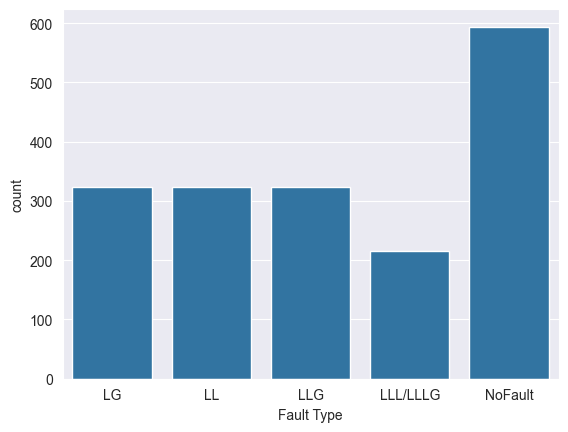

In [186]:
sns.countplot(x=f['Fault Type'])

In [187]:
le = LabelEncoder()
f['Fault Type'] = le.fit_transform(f['Fault Type'])

print(f.head())

                                       TransientData  Fault Type  Distance
0  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...           0      30.0
1  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...           0      60.0
2  [{'Va': 1.08326546064588e-17, 'Vb': -4.5008479...           0      90.0
3  [{'Va': -1.8340021196534344e-17, 'Vb': -5.0204...           0      30.0
4  [{'Va': -4.217271620480714e-18, 'Vb': -2.00127...           0      60.0


In [188]:
# This iterates through every simulation, expands the dictionaries, and stacks them
#X = np.array([pd.DataFrame.from_records(sim).values for sim in f['TransientData']])
features = ['D6[Va]', 'D6[Vb]', 'D6[Vc]', 'D6[Ia]', 'D6[Ib]', 'D6[Ic]', 'D2[Ia]', 'D2[Ib]', 'D2[Ic]', 'Ig']

X = np.array([
    pd.DataFrame(
    list(sim))[features].values for sim in f['TransientData']
])

#threshold = 1e-5
#X[np.abs(X) < threshold] = 1e-5

#X[ :, :21, 1:4] = 1e-5

X = X[:, 20:300, :]


features = ['Fault Type', 'Distance']
y = f[features].to_numpy()

print({X.shape}) 
print({y.shape})

{(1782, 280, 10)}
{(1782, 2)}


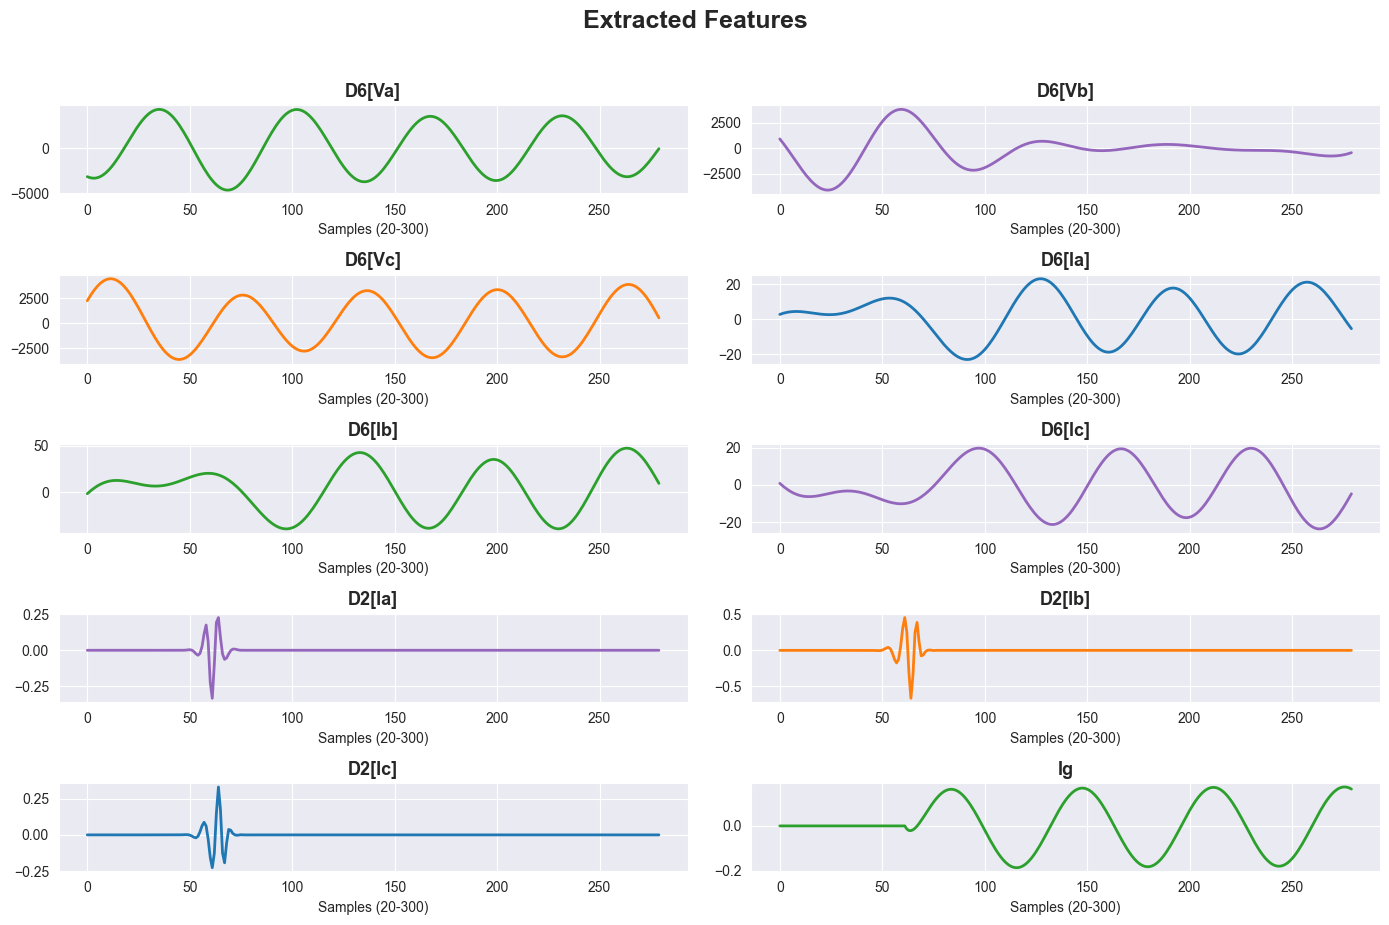

In [189]:
'D6[Va]', 'D6[Vb]', 'D6[Vc]', 'D6[Ia]', 'D6[Ib]', 'D6[Ic]', 'D2[Ia]', 'D2[Ib]', 'D2[Ic]', 'Ig'
n = 27

D6_Va = X[n, :, 0] 
D6_Vb = X[n, :, 1]
D6_Vc = X[n, :, 2]
D6_Ia = X[n, :, 3]
D6_Ib = X[n, :, 4]
D6_Ic = X[n, :, 5]
D2_Ia = X[n, :, 6]
D2_Ib = X[n, :, 7]
D2_Ic = X[n, :, 8]
Ig = X[n, :, 9]

fig = plt.figure(figsize=(14, 10))
plt.suptitle("Extracted Features", fontsize=18, fontweight='bold', y=0.95)

def style_plot(title):
    plt.title(title, fontsize=13, fontweight='semibold')
    plt.xlabel("Samples (20-300)", fontsize=10)

plt.subplot(5, 2, 1)
plt.plot(D6_Va, color='#2ca02c', linewidth=2)
style_plot("D6[Va]")

plt.subplot(5, 2, 2)
plt.plot(D6_Vb, color='#9467bd', linewidth=2)
style_plot("D6[Vb]")

plt.subplot(5, 2, 3)
plt.plot(D6_Vc, color='#ff7f0e', linewidth=2)
style_plot("D6[Vc]")

plt.subplot(5, 2, 4)
plt.plot(D6_Ia, color='#1f77b4', linewidth=2)
style_plot("D6[Ia]")

plt.subplot(5, 2, 5)
plt.plot(D6_Ib, color='#2ca02c', linewidth=2)
style_plot("D6[Ib]")

plt.subplot(5, 2, 6)
plt.plot(D6_Ic, color='#9467bd', linewidth=2)
style_plot("D6[Ic]")
plt.subplot(5, 2, 7)
plt.plot(D2_Ia, color='#9467bd', linewidth=2)
style_plot("D2[Ia]")

plt.subplot(5, 2, 8)
plt.plot(D2_Ib, color='#ff7f0e', linewidth=2)
style_plot("D2[Ib]")

plt.subplot(5, 2, 9)
plt.plot(D2_Ic, color='#1f77b4', linewidth=2)
style_plot("D2[Ic]")

plt.subplot(5, 2, 10)
plt.plot(Ig, color='#2ca02c', linewidth=2)
style_plot("Ig")

plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()


In [190]:
# 1. Group Scale (Columns 1 to 3) - Remains 3D
D6_V = X[:, :, 0:3]
scaler_D6_V = MinMaxScaler()
D6_V_reshaped = D6_V.reshape(-1, 3) 
scaler_D6_V.fit(D6_V_reshaped)
D6_V_scaled = scaler_D6_V.transform(D6_V_reshaped).reshape(D6_V.shape)

D6_I = X[:, :, 3:6]
scaler_D6_I = MinMaxScaler()
D6_I_reshaped = D6_I.reshape(-1, 3) 
scaler_D6_I.fit(D6_I_reshaped)
D6_I_scaled = scaler_D6_I.transform(D6_I_reshaped).reshape(D6_I.shape)

D2_I = X[:, :, 6:9]
scaler_D2_I = MinMaxScaler()
D2_I_reshaped = D2_I.reshape(-1, 3) 
scaler_D2_I.fit(D2_I_reshaped)
D2_I_scaled = scaler_D2_I.transform(D2_I_reshaped).reshape(D2_I.shape)

Xg = X[:, :, 9:10] 
Xg_reshaped = Xg.reshape(-1, 1)
scaler_X = MinMaxScaler()
scaler_X.fit(Xg_reshaped)
Xg_scaled = scaler_X.transform(Xg_reshaped).reshape(Xg.shape) 

# 3. Concatenate - Both are now 3D
X_final = np.concatenate((D6_V_scaled, D6_I_scaled, D2_I_scaled, Xg_scaled), axis=2)
print({X_final.shape})

#X_transformed = np.sign(X) * np.log10(np.abs(X) + 1e-15)

# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.25)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

scaler_y = MinMaxScaler()

y_train_class = y_train[:, 0]
y_train_dist = y_train[:, 1].reshape(-1, 1)
scaler_y.fit(y_train_dist)
y_train_dist_scaled = scaler_y.transform(y_train_dist)

y_train_dist_log = np.log1p(y_train_dist)

y_test_class = y_test[:, 0]
y_test_dist = y_test[:, 1].reshape(-1, 1)
y_test_dist_scaled = scaler_y.transform(y_test_dist)

y_test_dist_log = np.log1p(y_test_dist)

y_val_class = y_val[:, 0]
y_val_dist = y_val[:, 1].reshape(-1, 1)
y_val_dist_scaled = scaler_y.transform(y_val_dist)

y_val_dist_log = np.log1p(y_val_dist)

# only one-hot encode the CLASS
y_test_cat = tf.keras.utils.to_categorical(y_test_class)
y_val_cat = tf.keras.utils.to_categorical(y_val_class)
y_train_cat = tf.keras.utils.to_categorical(y_train_class)

{(1782, 280, 10)}


In [ ]:
# Define the input shape
inputs = tf.keras.layers.Input(shape=(280, 10))

# --- Shared Feature Extraction ---
# 1. Increase noise to simulate real-world sensor jitter
x = tf.keras.layers.GaussianNoise(0.05)(inputs) 

x = tf.keras.layers.Conv1D(64, 12, activation='leaky_relu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
x = tf.keras.layers.BatchNormalization()(x)
# We store this for the skip connection later
x = tf.keras.layers.MaxPooling1D(2)(x)

x = tf.keras.layers.Conv1D(64, 6, activation='leaky_relu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
res_1_conv = x 
x = tf.keras.layers.SpatialDropout1D(0.3)(x)
x = tf.keras.layers.MaxPooling1D(2)(x)

x = tf.keras.layers.Conv1D(128, 3, activation='leaky_relu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
# This represents the "Deep Features"
shared_avg = tf.keras.layers.GlobalAveragePooling1D()(x) 
shared_max = tf.keras.layers.GlobalMaxPooling1D()(x)

# --- Branch 1: Fault Type (Classification) ---
# Reduced units from 256 to 64. Overfitting usually happens in wide Dense layers.
type_x = tf.keras.layers.Dense(128, activation='leaky_relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4), activity_regularizer=tf.keras.regularizers.l2(1e-4))(shared_avg)
type_x = tf.keras.layers.Dropout(0.3)(type_x)
type_output = tf.keras.layers.Dense(5, activation='softmax', name='type')(type_x)

# --- Branch 2: Fault Distance (Regression) ---
# FIX: Ensure we are adding 1D vectors to 1D vectors
dist_x = tf.keras.layers.Dense(16, activation='leaky_relu')(shared_avg)
dist_x = tf.keras.layers.BatchNormalization()(dist_x)

# We GAP the early Conv layer so it matches the Dense layer shape (64 units)
res_1_gap = tf.keras.layers.GlobalAveragePooling1D()(res_1_conv)
res_1_gmp = tf.keras.layers.GlobalMaxPooling1D()(res_1_conv)

# The Skip Connection now adds "Raw Magnitude" to "Deep Features"
dist_x = tf.keras.layers.Concatenate()([dist_x, shared_max, res_1_gap, res_1_gmp]) 
dist_x = tf.keras.layers.GaussianNoise(0.01)(dist_x)
dist_x = tf.keras.layers.Dense(256, activation='leaky_relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4), activity_regularizer=tf.keras.regularizers.l2(1e-4))(dist_x)
dist_x = tf.keras.layers.BatchNormalization()(dist_x)
dist_x = tf.keras.layers.Dropout(0.2)(dist_x)
dist_x = tf.keras.layers.Dense(128, activation='leaky_relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4), activity_regularizer=tf.keras.regularizers.l2(1e-4))(dist_x)
dist_output = tf.keras.layers.Dense(1, activation='sigmoid', name='distance')(dist_x)
#dist_output = tf.keras.layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0), name='distance')(dist_output) 

model = tf.keras.Model(inputs=inputs, outputs=[type_output, dist_output])

# Balanced Weights: Type and Distance now have equal influence
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4), 
    loss={'type': tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 'distance': 'mse'},
    loss_weights={'type': 1.0, 'distance': 20.0}, 
    metrics={'type': 'accuracy', 'distance': 'mae'}
)

In [192]:
print(model.summary())

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 280, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_18   │ (None, 280, 10)   │          0 │ input_layer_9[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 280, 64)   │      7,744 │ gaussian_noise_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 280, 64)   │        256 │ conv1d_27[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_18    │ (None, 140, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 140, 64)   │     24,640 │ max_pooling1d_18… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_9 │ (None, 140, 64)   │          0 │ conv1d_28[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_19    │ (None, 70, 64)    │          0 │ spatial_dropout1… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 70, 128)   │     24,704 │ max_pooling1d_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv1d_29[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 16)        │      2,064 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_41[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_29[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv1d_28[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_28[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 272)       │          0 │ batch_normalizat… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_19   │ (None, 272)       │          0 │ concatenate_9[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 180,566 (705.34 KB)

 Trainable params: 179,894 (702.71 KB)

 Non-trainable params: 672 (2.62 KB)

None


In [193]:
model.compile(
    optimizer='adam', 
    loss={'type': 'categorical_crossentropy', 'distance': 'mse'},
    metrics={'type': 'accuracy', 'distance': 'mae'}
)

# 1. Create a weight array of 1.0s for all samples
#sample_weights = np.ones(shape=(len(y_train_class),))
#distance_weights = np.ones(shape=(len(y_train_class),))

# 2. Assign higher weights (e.g., 5.0) specifically to LLL and LLLG
# Assuming y_train_class contains the integer labels (0-5)
#sample_weights[y_train_class == 3] = 5.0
#sample_weights[y_train_class == 4] = 5.0

#k = np.select([(100 <=y_train_dist) & (y_train_dist <= 250), (250 < y_train_dist)], [3, 2], default=1.0)
#k_val = np.select([(100 <=y_val_dist) & (y_val_dist <= 250), (250 < y_val_dist)], [3, 2], default=1.0)

k = np.where((250 < y_train_dist), 2.0, 1.0)
k_val = np.where((250 < y_val_dist), 2.0, 1.0)

distance_weights = ((y_train_dist / np.max(y_train_dist)) + k) #** overshoot_boost_train
distance_weights_reshaped = np.array(distance_weights).flatten().astype('float32')  # Reshape to 1D for sample_weight
distance_weights_val = k_val * ((y_val_dist / np.max(y_val_dist)) + k_val) #** overshoot_boost_val
distance_weights_val_reshaped = np.array(distance_weights_val).flatten().astype('float32')  # Reshape to 1D for sample_weight
type_weights = np.ones(len(y_train_cat), dtype='float32')
type_weights_val = np.ones(len(y_val_cat), dtype='float32')

train_weights = [type_weights, distance_weights_reshaped]
val_weights = [type_weights_val, distance_weights_val_reshaped]

es = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True,
    start_from_epoch=30, 
    mode = 'min')

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)

print("Expected keys for weights:", model.output_names)

# Assuming y_train_cat is (Samples, 6) and y_train_dist_scaled is (Samples, 1)
history = model.fit(
    X_train, 
    [y_train_cat, y_train_dist_scaled], 
    epochs=100, 
    batch_size=64,
    sample_weight=[type_weights, distance_weights_reshaped],
    validation_data=(X_val, [y_val_cat, y_val_dist_scaled], [type_weights_val, distance_weights_val_reshaped]),
    callbacks=[es, reduce_lr]
)

Expected keys for weights: ListWrapper(['type', 'distance'])
Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 40s 713ms/step - distance_loss: 0.1370 - distance_mae: 0.2511 - loss: 2.4628 - type_accuracy: 0.3331 - type_loss: 1.5029 - val_distance_loss: 0.3635 - val_distance_mae: 0.3386 - val_loss: 2.1631 - val_type_accuracy: 0.3453 - val_type_loss: 1.5772 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - distance_loss: 0.0911 - distance_mae: 0.1919 - loss: 1.8359 - type_accuracy: 0.4753 - type_loss: 1.2568 - val_distance_loss: 0.3491 - val_distance_mae: 0.3411 - val_loss: 2.2327 - val_type_accuracy: 0.1525 - val_type_loss: 1.6709 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - distance_loss: 0.0725 - distance_mae: 0.1681 - loss: 1.5034 - type_accuracy: 0.5786 - type_loss: 0.9819 - val_distance_loss: 0.3437 - val_distance_mae: 0.3424 - val_loss: 2.2810 - val_type_accuracy: 0.2242 - val_type_loss: 1.7302 - learning_rate: 0.0010
Epoch 4/100

In [194]:
# 1. Get raw predictions (Returns a list of 2 arrays)
# predictions[0] = Fault Type probabilities
# predictions[1] = Scaled Distance
predictions = model.predict(X_test)

# 2. Extract and Process Fault Types (Classification Head)
y_pred_probs = predictions[0] 
y_pred_class = np.argmax(y_pred_probs, axis=1)
# Use your categorical y_test data (index 0 to 5)
y_test_class = np.argmax(y_test_cat, axis=1) 

# 3. Extract and Process Distance (Regression Head)
y_pred_dist_scaled = predictions[1]
# Use your scaled y_test distance data
y_test_dist_scaled = y_test_dist_scaled

# 4. Un-scale the distance back to meters
y_pred_dist_m = scaler_y.inverse_transform(y_pred_dist_scaled)
y_test_dist_m = scaler_y.inverse_transform(y_test_dist_scaled.reshape(-1, 1))
#y_pred_dist_m = np.expm1(y_pred_dist_log)
#y_test_dist_m = np.expm1(y_test_dist_log.reshape(-1, 1))

print("--- FAULT TYPE CLASSIFICATION REPORT ---")
target_names = ['LG', 'LL', 'LLG', 'LLL/LLLG', 'No Fault']
print(classification_report(y_test_class, y_pred_class, target_names=target_names))

mae_m = mean_absolute_error(y_test_dist_m, y_pred_dist_m)
r2 = r2_score(y_test_dist_m, y_pred_dist_m)

print("--- DISTANCE ESTIMATION ACCURACY ---")
print(f"Average Location Error: {mae_m:.2f}")
print(f"R2 Score (Model Fit): {r2:.4f}")

print(f"{'Actual Type':<12} | {'Pred Type':<12} | {'Actual Dist':<12} | {'Pred Dist':<12}")
print("-" * 65)
for i in range(15): # Checking the first 15 samples
    act_t = target_names[y_test_class[i]]
    pre_t = target_names[y_pred_class[i]]
    act_d = y_test_dist_m[i][0]
    pre_d = y_pred_dist_m[i][0]
    
    print(f"{act_t:<12} | {pre_t:<12} | {act_d:<10.2f} | {pre_d:<10.2f} ")

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 494ms/step
--- FAULT TYPE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          LG       1.00      1.00      1.00        42
          LL       1.00      1.00      1.00        44
         LLG       1.00      1.00      1.00        34
    LLL/LLLG       1.00      1.00      1.00        29
    No Fault       1.00      1.00      1.00        74

    accuracy                           1.00       223
   macro avg       1.00      1.00      1.00       223
weighted avg       1.00      1.00      1.00       223

--- DISTANCE ESTIMATION ACCURACY ---
Average Location Error: 29.97
R2 Score (Model Fit): 0.9145
Actual Type  | Pred Type    | Actual Dist  | Pred Dist   
-----------------------------------------------------------------
LL           | LL           | 130.00     | 246.96     
LL           | LL           | 60.00      | 93.03      
LLL/LLLG     | LLL/LLLG     | 390.00     | 347.55     
LLL/LLLG     | LLL/LLLG     | 330.00     | 30

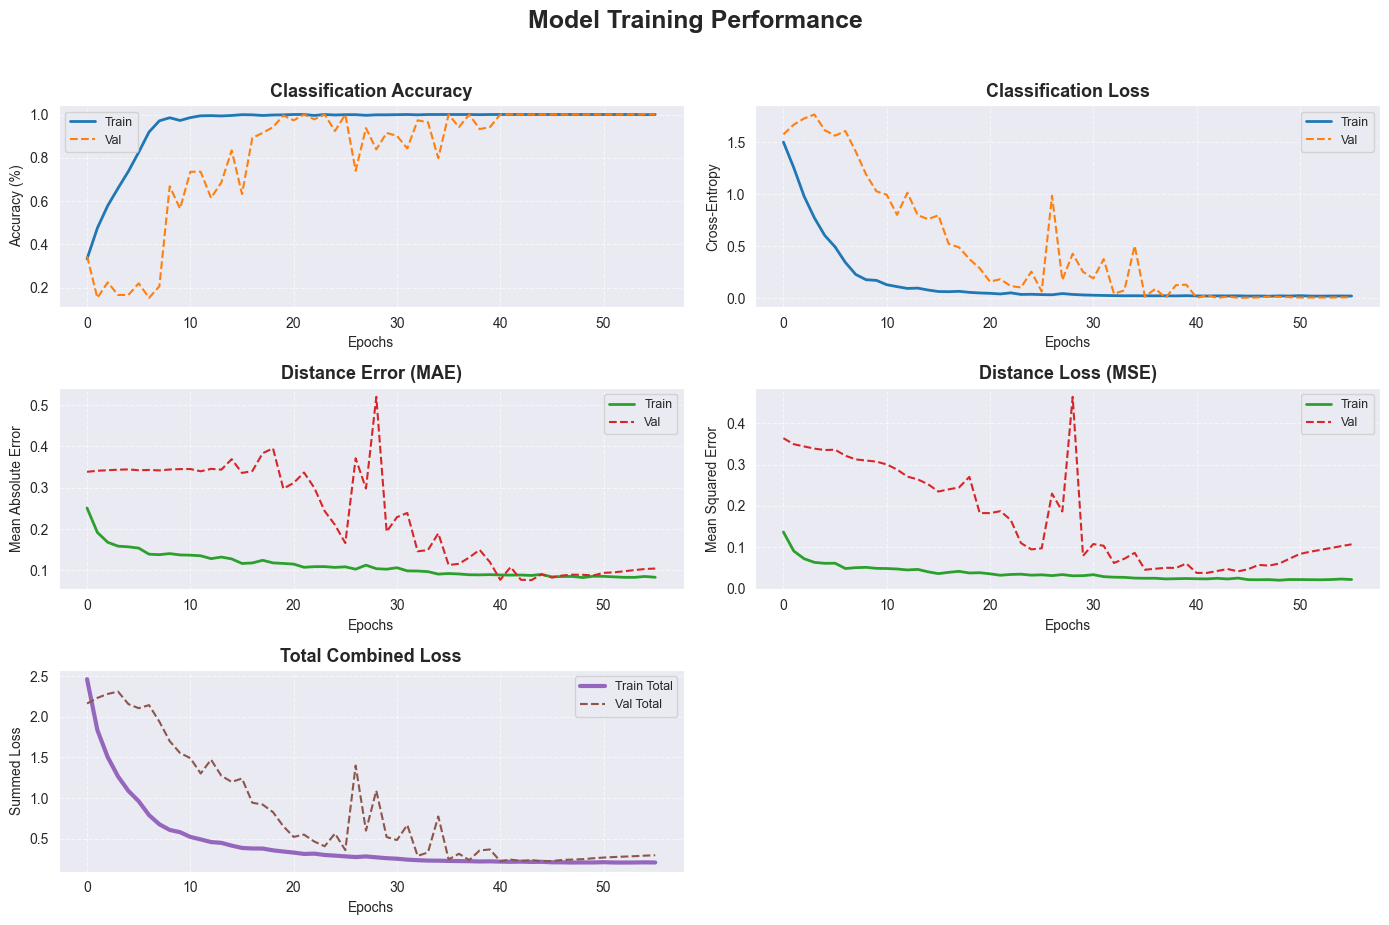

In [195]:
# 1. Increase figure size for 5 subplots
fig = plt.figure(figsize=(14, 10))
plt.suptitle("Model Training Performance", fontsize=18, fontweight='bold', y=0.95)

# Helper function to style each subplot consistently
def style_plot(title, ylabel):
    plt.title(title, fontsize=13, fontweight='semibold')
    plt.xlabel("Epochs", fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=9)

# --- 1. Type Accuracy ---
plt.subplot(3, 2, 1)
plt.plot(history.history["type_accuracy"], label='Train', color='#1f77b4', linewidth=2)
plt.plot(history.history["val_type_accuracy"], label='Val', color='#ff7f0e', linestyle='--')
style_plot("Classification Accuracy", "Accuracy (%)")

# --- 2. Type Loss ---
plt.subplot(3, 2, 2)
plt.plot(history.history["type_loss"], label='Train', color='#1f77b4', linewidth=2)
plt.plot(history.history["val_type_loss"], label='Val', color='#ff7f0e', linestyle='--')
style_plot("Classification Loss", "Cross-Entropy")

# --- 3. Distance MAE ---
plt.subplot(3, 2, 3)
plt.plot(history.history["distance_mae"], label='Train', color='#2ca02c', linewidth=2)
plt.plot(history.history["val_distance_mae"], label='Val', color='#d62728', linestyle='--')
style_plot("Distance Error (MAE)", "Mean Absolute Error")


# --- 4. Distance Loss (MSE) ---
plt.subplot(3, 2, 4)
plt.plot(history.history["distance_loss"], label='Train', color='#2ca02c', linewidth=2)
plt.plot(history.history["val_distance_loss"], label='Val', color='#d62728', linestyle='--')
style_plot("Distance Loss (MSE)", "Mean Squared Error")

# --- 5. Total Combined Loss ---
plt.subplot(3, 2, 5)
plt.plot(history.history["loss"], label='Train Total', color='#9467bd', linewidth=3)
plt.plot(history.history["val_loss"], label='Val Total', color='#8c564b', linestyle='--')
style_plot("Total Combined Loss", "Summed Loss")

# 2. Prevent overlapping labels
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()

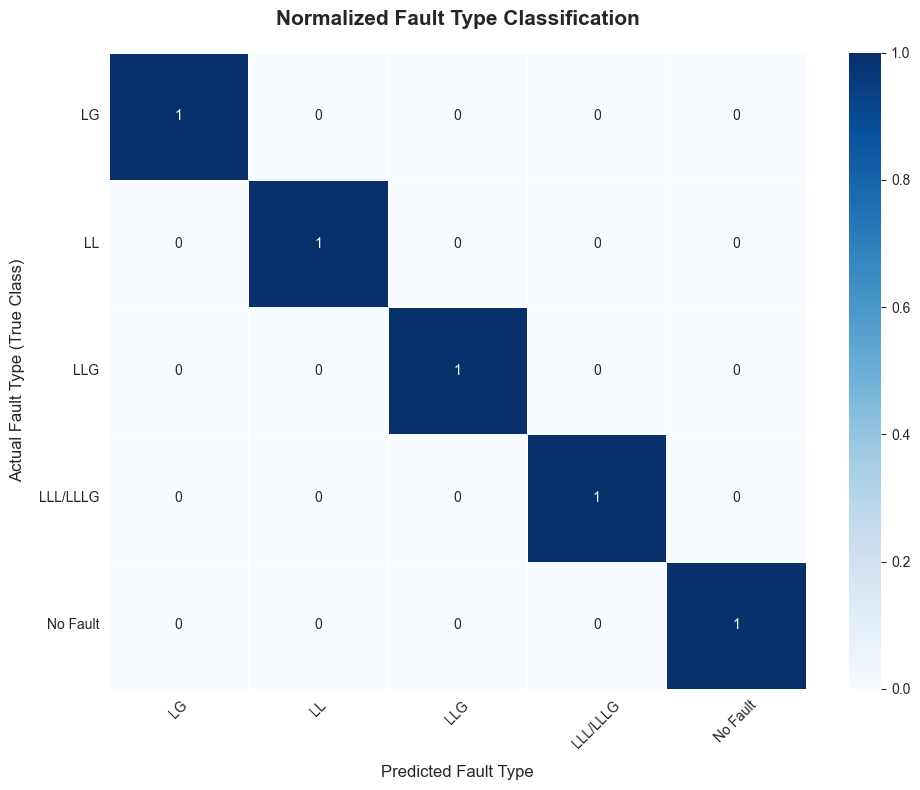

In [196]:
# 1. Define labels
target_names = ['LG', 'LL', 'LLG', 'LLL/LLLG', 'No Fault']

# 2. Generate the raw matrix
cf_matrix = confusion_matrix(np.argmax(y_test_cat, axis=1), np.argmax(y_pred_probs, axis=1))

# Divide each row by its sum to get percentages (0.0 to 1.0)
# We use np.newaxis to ensure the division happens row-by-row
cf_normalized = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]

# 3. Plotting
plt.figure(figsize=(10, 8))

# We use cf_normalized for the colors, but "fmt='.2%'" to show percentages
sns.heatmap(cf_normalized, 
            annot=True,  
            cmap="Blues", 
            xticklabels=target_names, 
            yticklabels=target_names,
            linewidths=.5)

plt.title("Normalized Fault Type Classification", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Predicted Fault Type", fontsize=12, labelpad=10)
plt.ylabel("Actual Fault Type (True Class)", fontsize=12, labelpad=10)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

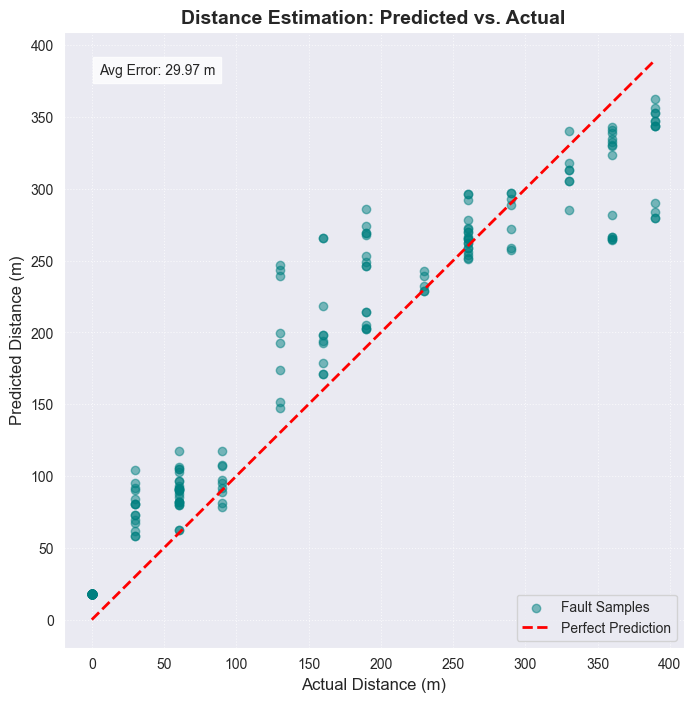

In [197]:
# 1. Create the plot
plt.figure(figsize=(8, 8))

# 2. Scatter plot of Actual vs Predicted
plt.scatter(y_test_dist_m, y_pred_dist_m, alpha=0.5, color='teal', label='Fault Samples')

# 3. The "Perfect Prediction" Line
# We draw a line from the min distance to the max distance
limits = [np.min(y_test_dist_m), np.max(y_test_dist_m)]
plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("Distance Estimation: Predicted vs. Actual", fontsize=14, fontweight='bold')
plt.xlabel("Actual Distance (m)", fontsize=12)
plt.ylabel("Predicted Distance (m)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# 4. Add a text box with the MAE
mae_m = mean_absolute_error(y_test_dist_m, y_pred_dist_m)
plt.text(limits[0]+5, limits[1]-10, f'Avg Error: {mae_m:.2f} m', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

In [198]:
# The "Gain" you need is (max - min)
gain_y = scaler_y.data_max_[0] - scaler_y.data_min_[0]

# The "Offset" is the minimum value
offset_y = scaler_y.data_min_[0]

print(f"Gain[distance]: {gain_y}")
print(f"Offset[distance]: {offset_y}")

Gain[distance]: 390.0
Offset[distance]: 0.0


In [199]:
# save the model
model.save("CNNmodel.keras")